# From nodal values to calculus

We store a quadratic at $0,\tfrac12,1$. We will construct its **Lagrange basis**, reconstruct the polynomial, and turn differentiation and integration into fixed arrays.

Run the cells in order in Colab. We use SymPy for exact arithmetic; `Rational(1, 2)` keeps fractions exact.

In [1]:
import sympy as sp
from IPython.display import display
sp.init_printing()

tau = sp.symbols('tau')
half = sp.Rational(1, 2)

## 1. Construct each cardinal function

Each function must be one at its own node and zero at the other two. Put those other nodes in the numerator, then divide by the value of that numerator at its own node. Here $m$ labels the midpoint.

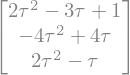

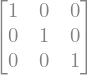

In [2]:
ell_0 = (tau - half)*(tau - 1) / ((0 - half)*(0 - 1))
ell_m = (tau - 0)*(tau - 1) / ((half - 0)*(half - 1))
ell_1 = (tau - 0)*(tau - half) / ((1 - 0)*(1 - half))

ell = sp.Matrix([ell_0, ell_m, ell_1])
display(sp.expand(ell))

# Each row evaluates all three basis functions at one node.
E = sp.Matrix.vstack(ell.subs(tau, 0).T,
                     ell.subs(tau, half).T,
                     ell.subs(tau, 1).T)
display(E)  # Identity: each node selects its own coefficient.
assert E == sp.eye(3)

## 2. Reconstruct the polynomial

The coefficients in this basis are the stored values:
$$p(\tau)=y_0\ell_0(\tau)+y_m\ell_m(\tau)+y_1\ell_1(\tau).$$
Use $\mathbf y=(1,\tfrac74,2)^\top$. Predict the polynomial before expanding.

In [3]:
y = sp.Matrix([1, sp.Rational(7, 4), 2])
p = sp.expand(y[0]*ell_0 + y[1]*ell_m + y[2]*ell_1)
display(p)  # 1 + 2*tau - tau**2

display(p.subs(tau, sp.Rational(1, 4)))  # Value between nodes: 23/16.

## 3. Differentiate using a matrix

Since the $y_j$ are constant with respect to $\tau$,
$$p'(\sigma_i)=\sum_j\ell_j'(\sigma_i)y_j.$$
Thus row $i$ of $D$ contains the derivatives of the three basis functions at node $\sigma_i$. Differentiating the basis once lets us compute slopes for any new nodal values by multiplying $D\mathbf y$.

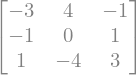

In [4]:
d_ell = ell.diff(tau)
D = sp.Matrix.vstack(d_ell.subs(tau, 0).T,
                     d_ell.subs(tau, half).T,
                     d_ell.subs(tau, 1).T)
display(D)
display(D*y)  # Slopes at 0, 1/2, 1: (2, 1, 0).

# Check against direct differentiation of the reconstructed polynomial.
dp = sp.diff(p, tau)
assert D*y == sp.Matrix([dp.subs(tau, 0),
                        dp.subs(tau, half), dp.subs(tau, 1)])

## 4. Integrate using a row of weights

Integrating the same expansion gives
$$\int_0^1p(\tau)\,d\tau=\sum_j y_j\int_0^1\ell_j(\tau)\,d\tau=\mathbf w^\top\mathbf y.$$
Each weight is the signed area under one basis function. The weights depend on the nodes, so they can be reused when $\mathbf y$ changes.

In [5]:
w = sp.Matrix([sp.integrate(ell_0, (tau, 0, 1)),
               sp.integrate(ell_m, (tau, 0, 1)),
               sp.integrate(ell_1, (tau, 0, 1))])
display(w.T)  # [1/6, 2/3, 1/6]
area = (w.T*y)[0]
display(area)  # 5/3
assert area == sp.integrate(p, (tau, 0, 1))

## Try it

Change the midpoint value from $7/4$ to $3$ in the reconstruction cell and rerun the remaining cells. Predict which quantities stay fixed. Check that the polynomial changes by $\tfrac54\ell_m(\tau)$ and its integral increases by $5/6$.

These operations are exact for the represented quadratic. On a physical interval $t=t_k+h_k\tau$, physical-time slopes are $D\mathbf y/h_k$ and the integral is $h_k\mathbf w^\top\mathbf y$.